# Plot baseline results
- This script is used to visualize very hot days and hot nights.
- Simulation: CNTL

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import string
home_path = '/gws/ssde/j25a/duicv/yuansun/'
project_path = f'{home_path}0_wrf-cstm_GM-HK/'
scenario_list = ['cntl']

In [2]:
df_metric = pd.read_csv(f'data_for_figure/extreme_heat_metrics.csv')
df_metric['date'] = pd.to_datetime(df_metric['date'])
df_metric['month'] = df_metric['date'].dt.month
df_metric['year'] = df_metric['date'].dt.year
df_metric.head()

,date,values,variable,senario,metric,month,year
0,2035-05-30,33.441740,TSA,cntl,vhds,5,2035
1,2035-05-31,33.385036,TSA,cntl,vhds,5,2035
2,2035-06-02,33.023796,TSA,cntl,vhds,6,2035
3,2035-06-07,33.083687,TSA,cntl,vhds,6,2035
4,2035-06-08,33.182170,TSA,cntl,vhds,6,2035


In [3]:
lc1 = '#4daf4a'
lc2 = '#377eb8'
lc3 = '#ff7f00'
lc4 = '#e41a1c'
lc5 = '#984ea3'
lc_dict = {2035: lc1, 2036: lc2, 2037: lc3, 2038: lc4, 2039: lc5}
nrows = 2
ncols = 2
column_list = ['count', 'magnitude']
title_list = ['Number of VHDs', r'Median daily maximum 2m air temperature of VHDs', 
              'Number of HNs', r'Median daily maximum 2m air temperature of HNs']
fontsize = 6
labelcolor = '#6b6b6b'
boundarywidth = 0.5
labelsize = 6
length = 4
pad = 1
padding = 4
handletextpad = 0.5
yoffset = 0.085

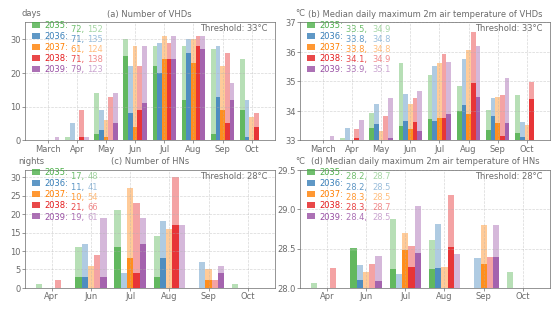

In [4]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5, 3))
ax = axes.flatten()
for i in range(nrows*ncols):
    index_day = i // ncols
    index_col = i % ncols
    metric = ['vhds', 'hns'][index_day]
    df_metric_grid = df_metric[(df_metric['metric'] == metric) & (df_metric['variable'] == 'TSA')].copy()
    df_metric_urban = df_metric[(df_metric['metric'] == metric) & (df_metric['variable'] == 'TSA_U')].copy()
    unit = ['days', '°C', 'nights', '°C'][i]
    if index_col ==0: # count
        aggfunc = 'count'
        ymin = 0
        ylabel_xloc = 0.025
        decimal = 0
        xloc = 0.25
        if index_day ==0:
            ymax = 35
            threshold = 33
        else:    
            ymax = 32
            threshold = 28
    else:
        aggfunc = 'median'
        ylabel_xloc = 0
        decimal = 1
        xloc = 0.29
        if index_day ==0:
            ymin = 33
            ymax = 37
            threshold = 33
        else:
            ymin = 28
            ymax = 29
            threshold = 28
    ax[i].text(0.7, 0.925, f'Threshold: {threshold}°C', color=labelcolor, fontsize=fontsize, transform=ax[i].transAxes)   
    if index_day ==0:
        months_list = ['March', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct'] 
    else:
        months_list = ['Apr', 'Jun', 'Jul', 'Aug', 'Sep','Oct' ]                 
    urban_pivot_counts = df_metric_urban.pivot_table(index='month', columns='year', values='values', aggfunc=aggfunc)
    urban_pivot_counts = urban_pivot_counts.fillna(0)
    months = urban_pivot_counts.index
    years = urban_pivot_counts.columns
    n_months = len(months)
    n_years = len(years)
    pivot_counts = df_metric_grid.pivot_table(index='month', columns='year', values='values', aggfunc=aggfunc)
    pivot_counts = pivot_counts.reindex(urban_pivot_counts.index)
    pivot_counts = pivot_counts.fillna(0)
    bar_width = 0.8 / n_years
    x = np.arange(n_months)
    df_metric_grid_annual = df_metric_grid.groupby(['year']).agg({'values': aggfunc}).reset_index()
    df_metric_urban_annual = df_metric_urban.groupby(['year']).agg({'values': aggfunc}).reset_index()

    for j, year in enumerate(years):
        bars_urban = ax[i].bar(x + j * bar_width, urban_pivot_counts[year], width=bar_width, 
                         color=lc_dict[year], alpha=0.4)
        bars = ax[i].bar(x + j * bar_width, pivot_counts[year], width=bar_width, label=f'{str(year)}:', 
                         color=lc_dict[year], alpha=0.8)
        ax[i].text(0.185, 0.92-yoffset*j, f'{np.round(df_metric_grid_annual.iloc[j]["values"], decimal)}, ', transform=ax[i].transAxes,
                        fontsize=fontsize, color=lc_dict[year], alpha=0.8)    
        ax[i].text(xloc, 0.92-yoffset*j, np.round(df_metric_urban_annual.iloc[j]['values'], decimal), transform=ax[i].transAxes,
                        fontsize=fontsize, color=lc_dict[year], alpha=0.5)    
    ax[i].set_xticks(x + bar_width * (n_years - 1) / 2)
    ax[i].set_xticklabels(months_list)
    ax[i].set_ylim(ymin, ymax)
    ax[i].tick_params(axis='y', labelleft=True, labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)
    ax[i].tick_params(axis='x', labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)
    title_name = f'({string.ascii_lowercase[i]}) {title_list[i]}'
    ax[i].set_title(title_name, fontsize=fontsize, color=labelcolor, pad=padding)
    ax[i].grid(True,linestyle='--',linewidth=0.5, alpha=0.5)
    step = [10, 1, 5, 0.5][i]
    yticks = np.arange(ymin, ymax+1, step)
    ax[i].set_yticks(yticks)
    ax[i].set_ylabel(unit, labelpad=5, rotation=0, ha='center', fontsize=labelsize,color=labelcolor)
    ax[i].yaxis.set_label_coords(ylabel_xloc, 1.035)
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor)
    lines, labels = ax[i].get_legend_handles_labels()
    legend = ax[i].legend(lines, labels, bbox_to_anchor=(0.1, 0.5), loc='lower center', frameon=False, 
                          handletextpad=handletextpad, fontsize=labelsize, ncol=1, handlelength=1, labelspacing=0.25)
    for t, text in enumerate(legend.get_texts()):
        text.set_color([lc1, lc2, lc3, lc4, lc5][t])
    
plt.subplots_adjust(left=0.035, right=0.99, bottom=0.065, top=0.95, wspace=0.1, hspace=0.25) 
fig.savefig('hk_extreme_heat_days.png', dpi=300)  
fig.savefig('hk_extreme_heat_days.pdf', dpi=600)       

# Description

In [4]:
df_metric_tsa = df_metric[(df_metric['variable'] == 'TSA')]
df_vhds_tsa = df_metric_tsa[df_metric_tsa['metric'] == 'vhds']
df_vhds_tsa_counts_annual = df_vhds_tsa.groupby(['year', 'variable']).agg({'values': 'count'}).reset_index()
df_vhds_tsa_counts_annual

,year,variable,values
0,2035,TSA,72
1,2036,TSA,71
2,2037,TSA,61
3,2038,TSA,71
4,2039,TSA,79


In [5]:
df_vhds_tsa_magnitude_annual = df_vhds_tsa.groupby(['year', 'variable']).agg({'values': 'mean'}).reset_index()
df_vhds_tsa_magnitude_annual['values'] = np.round(df_vhds_tsa_magnitude_annual['values'], 1)
df_vhds_tsa_magnitude_annual

,year,variable,values
0,2035,TSA,33.7
1,2036,TSA,34.0
2,2037,TSA,33.8
3,2038,TSA,34.3
4,2039,TSA,34.0


In [6]:
df_metric_tsa = df_metric[(df_metric['variable'] == 'TSA')]
df_hns_tsa = df_metric_tsa[df_metric_tsa['metric'] == 'hns']
df_hns_tsa_counts_annual = df_hns_tsa.groupby(['year', 'variable']).agg({'values': 'count'}).reset_index()
df_hns_tsa_counts_annual

,year,variable,values
0,2035,TSA,17
1,2036,TSA,11
2,2037,TSA,10
3,2038,TSA,21
4,2039,TSA,19


In [7]:
df_metric_tsau = df_metric[(df_metric['variable'] == 'TSA_U')]
df_vhds_tsau = df_metric_tsau[df_metric_tsau['metric'] == 'vhds']
df_vhds_tsau_counts_annual = df_vhds_tsau.groupby(['year', 'variable']).agg({'values': 'count'}).reset_index()
df_vhds_tsau_counts_annual

,year,variable,values
0,2035,TSA_U,152
1,2036,TSA_U,135
2,2037,TSA_U,124
3,2038,TSA_U,138
4,2039,TSA_U,123


In [8]:
df_vhds_tsau_magnitude_annual = df_vhds_tsau.groupby(['year', 'variable']).agg({'values': 'mean'}).reset_index()
df_vhds_tsau_magnitude_annual['values'] = np.round(df_vhds_tsau_magnitude_annual['values'], 1)
df_vhds_tsau_magnitude_annual['diff_grid'] = df_vhds_tsau_magnitude_annual['values'] - df_vhds_tsa_magnitude_annual['values']
df_vhds_tsau_magnitude_annual

,year,variable,values,diff_grid
0,2035,TSA_U,34.9,1.2
1,2036,TSA_U,34.9,0.9
2,2037,TSA_U,34.9,1.1
3,2038,TSA_U,35.2,0.9
4,2039,TSA_U,35.3,1.3


In [18]:
df_metric_tsau = df_metric[(df_metric['variable'] == 'TSA_U')]
df_hns_tsau = df_metric_tsau[df_metric_tsau['metric'] == 'hns']
df_hns_tsau_counts_annual = df_hns_tsau.groupby(['year', 'variable']).agg({'values': 'count'}).reset_index()
df_hns_tsau_counts_annual['diff_grid'] = df_hns_tsau_counts_annual['values'] - df_hns_tsa_counts_annual['values']
df_hns_tsau_counts_annual['diff_vhds'] = df_hns_tsau_counts_annual['values'] - df_vhds_tsau_counts_annual['values']
df_hns_tsau_counts_annual['account'] = np.round(100 * df_hns_tsau_counts_annual['values'] / df_vhds_tsau_counts_annual['values'], 1)
df_hns_tsau_counts_annual

,year,variable,values,diff_grid,diff_vhds,account
0,2035,TSA_U,48,31,-104,31.6
1,2036,TSA_U,41,30,-94,30.4
2,2037,TSA_U,54,44,-70,43.5
3,2038,TSA_U,66,45,-72,47.8
4,2039,TSA_U,61,42,-62,49.6
